In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from __future__ import annotations

import re
from pathlib import Path
from typing import Union

Функция для считывания данных с txt файлика

In [2]:
def parse_oscilloscope_txt(
    file_path: Union[str, Path],
    time_col: str = "time",
    value_col: str = "voltage",
    return_metadata: bool = False,
):
    """
    Парсит текстовый файл с данными осциллографа в pandas.DataFrame.

    Параметры
    ----------
    file_path : str | Path
        Путь к txt-файлу.
    time_col : str
        Имя столбца времени.
    value_col : str
        Имя столбца сигнала.
    return_metadata : bool
        Если True, дополнительно возвращает словарь с метаданными из заголовка.

    Возвращает
    ----------
    pd.DataFrame
        DataFrame со столбцами [time_col, value_col]
    или
    (pd.DataFrame, dict)
        Если return_metadata=True
    """
    file_path = Path(file_path)

    with file_path.open("r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    metadata = {}
    data_started = False
    data_rows = []

    # Паттерн для двух чисел в строке:
    # поддерживает обычную и экспоненциальную запись
    number = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
    pair_pattern = re.compile(rf"^\s*({number})\s+({number})\s*$")

    for line in lines:
        stripped = line.strip()

        # Ищем начало блока данных
        if not data_started:
            if stripped.startswith("Data as Time Sequence"):
                data_started = True
                continue

            # Пытаемся вытащить метаданные формата "key: value"
            if ":" in line:
                key, value = line.split(":", 1)
                metadata[key.strip()] = value.strip()

            continue

        # После начала данных пропускаем пустые и служебные строки
        if not stripped:
            continue

        match = pair_pattern.match(line)
        if match:
            t, y = match.groups()
            data_rows.append((float(t), float(y)))

    if not data_rows:
        raise ValueError(
            "Не удалось найти числовой блок данных. "
            "Проверьте формат файла."
        )

    df = pd.DataFrame(data_rows, columns=[time_col, value_col])

    if return_metadata:
        return df, metadata
    return df

Считываем данные

In [3]:
data16 = parse_oscilloscope_txt("data16.txt")

data16.head()

,time,voltage
0,0.0000,2.4033
1,0.0001,2.3641
2,0.0002,2.3250
3,0.0003,2.2744
4,0.0004,2.2239


In [4]:
data24 = parse_oscilloscope_txt("data24.txt")

data24.head()

,time,voltage
0,0.0000,2.7101
1,0.0001,2.7038
2,0.0002,2.6962
3,0.0003,2.6785
4,0.0004,2.6634


код для вычисления интенсивности и видности

In [5]:
def compute_intensity_and_visibility(
    df: pd.DataFrame,
    time_col: str = "time",
    signal_col: str = "voltage",
    window_points: int = 1001,
    baseline_correction: bool = False,
):
    """
    Строит локальные интенсивность и видность по временному сигналу.

    Параметры
    ---------
    df : DataFrame
        Должен содержать столбцы time и signal.
    window_points : int
        Размер скользящего окна в точках.
        Должен быть нечётным.
    baseline_correction : bool
        Если True, вычитается медленная составляющая через rolling mean.

    Возвращает
    ----------
    result : DataFrame
        Столбцы:
        - time
        - intensity
        - local_max
        - local_min
        - visibility
    """
    if window_points < 3:
        raise ValueError("window_points должен быть >= 3")
    if window_points % 2 == 0:
        window_points += 1  # делаем нечётным

    result = df[[time_col, signal_col]].copy()
    result = result.rename(columns={time_col: "time", signal_col: "intensity"})

    if baseline_correction:
        trend = (
            result["intensity"]
            .rolling(window=window_points, center=True, min_periods=1)
            .mean()
        )
        result["intensity"] = result["intensity"] - trend

    # локальные максимум и минимум в скользящем окне
    result["local_max"] = (
        result["intensity"]
        .rolling(window=window_points, center=True, min_periods=1)
        .max()
    )
    result["local_min"] = (
        result["intensity"]
        .rolling(window=window_points, center=True, min_periods=1)
        .min()
    )

    denom = result["local_max"] + result["local_min"]

    # избегаем деления на ноль
    result["visibility"] = np.where(
        np.abs(denom) > 1e-15,
        (result["local_max"] - result["local_min"]) / denom,
        np.nan,
    )

    return result


def plot_intensity_and_visibility(result: pd.DataFrame, save_name = None, title = None):
    """
    Рисует два графика:
    1) интенсивность от времени
    2) видность от времени
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    if title is not None:
        axes[0].set_title(title)

    axes[0].plot(result["time"], result["intensity"], linewidth=1)
    axes[0].set_ylabel("Интенсивность / сигнал")
    axes[0].grid(True)

    axes[1].plot(result["time"], result["visibility"], linewidth=1)
    axes[1].set_xlabel("Время, с")
    axes[1].set_ylabel("Видность")
    axes[1].set_title("Видность от времени")
    axes[1].grid(True)

    # plt.tight_layout()
    if save_name is not None:
        fig.savefig(f"pictures/{save_name}")
    plt.show()

Для $L = 16$ см

In [6]:
len(data16)

6000000

In [22]:
result16 = compute_intensity_and_visibility(
    df=data16,
    time_col="time",
    signal_col="voltage",
    window_points=10000
)

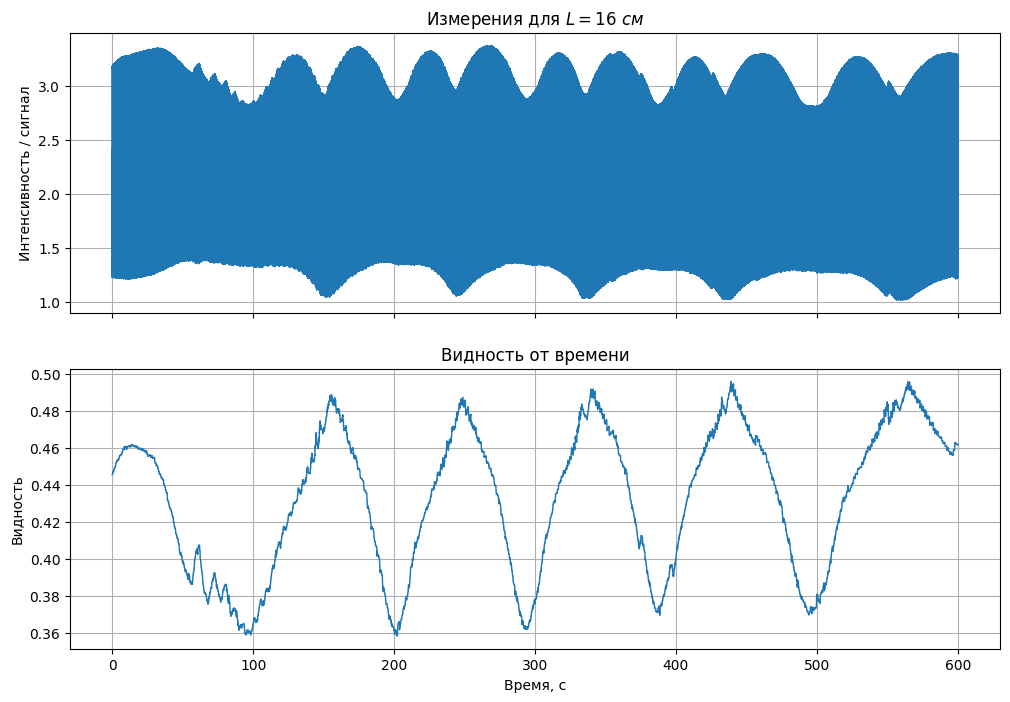

In [23]:
plot_intensity_and_visibility(
    result=result16,
    title=r"Измерения для $L = 16~см$",
    save_name="graph-16.pdf"
)

Для $L = 24$ см

In [9]:
len(data24)

6000000

In [20]:
result24 = compute_intensity_and_visibility(
    df=data24,
    time_col="time",
    signal_col="voltage",
    window_points=10000
)

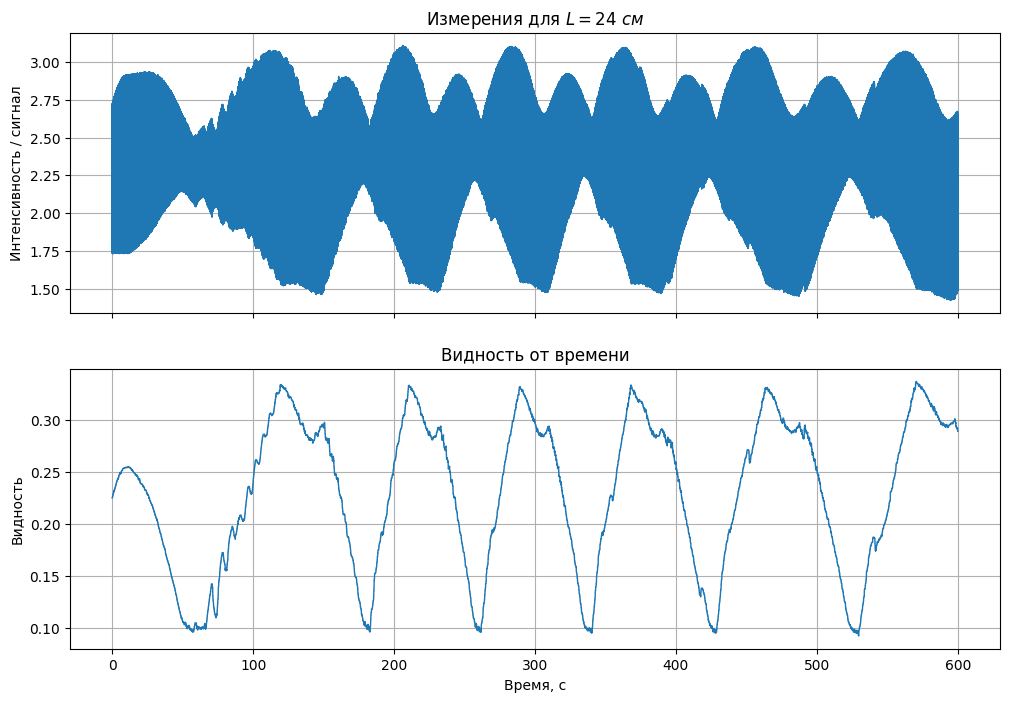

In [21]:
plot_intensity_and_visibility(
    result=result24,
    title=r"Измерения для $L = 24~см$",
    save_name="graph-24.pdf"
)